In [29]:
# pip install libraries
!pip install sentence-transformers faiss-cpu langchain
!pip install pypdf langchain_community
!pip install langchain-text-splitters

In [30]:
# upload the document
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
  print("uploaded:",filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report (2).pdf
uploaded: Microsoft 2025 Annual Report (2).pdf


In [31]:
# document ingestion pipeline
from langchain_community.document_loaders import PyPDFLoader
pdf_file = list(uploaded.keys())[0]
loader = PyPDFLoader(pdf_file) # loader object
documents = loader.load()
print("Number of pages loaded",len(documents))


Number of pages loaded 61


In [32]:
print(documents[0])

page_content='HomeShareholder LetterFinancial Review
Directors & OfﬁcersInvestor Relations
Business
Discussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotes
Auditor's ReportControls & Procedures
GeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable Information
Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
shareholder letter  
05/05/2026, 21:34 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 1/61' metadata={'producer': 'Skia/PDF m147', 'creato

In [33]:
# Chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
chunks = text_splitter.split_documents(documents)
print("total chunks created",len(chunks))

total chunks created 702


In [34]:
# Displaying 1 chunk
print(chunks[0].page_content)

HomeShareholder LetterFinancial Review
Directors & OfﬁcersInvestor Relations
Business
Discussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotes
Auditor's ReportControls & Procedures
GeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable Information


In [35]:
# embeddings from the chunk
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

#defining the embedding model
model = SentenceTransformer('all-MiniLM-L6-V2') # 22M parameters only , smaller model

#creating the embeddings
embeddings = model.encode([chunk.page_content for chunk in chunks]) #for each chunks in the chunk

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Total vectors in the index ",index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-V2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total vectors in the index  702


In [36]:
print(dimension)

384


In [37]:
import matplotlib.pyplot as plt
def visualize_embedding(vector,chunk_text=None,max_text_chars=500):
  vector = np.array(vector)
  normalized = (vector - vector.min())/(vector.max()-vector.min())
  color_band = normalized.reshape(1,-1)

  if chunk_text is not None:
    print("Chunk text \n")
    print(chunk_text[:max_text_chars])
    print()

    plt.figure(figsize =(12,2))
    plt.imshow(color_band,aspect="auto",cmap="viridis")
    plt.yticks([])
    plt.xlabel(f"Embedding Dimensions ({len(vector)})")
    plt.title("vector representation")
    plt.show()

Chunk text 

Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
shareholder letter  
05/05/2026, 21:34 Microsoft 2025 Annual Report



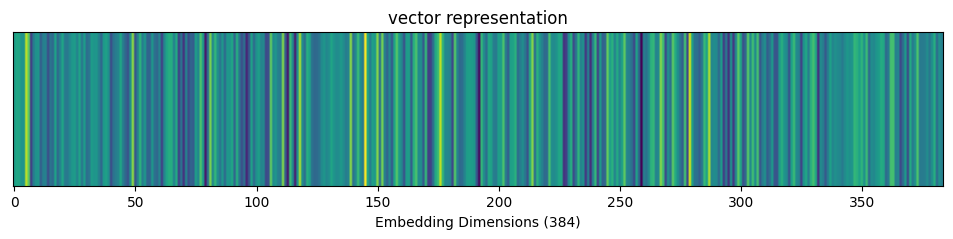

In [38]:
visualize_embedding(embeddings[1],chunks[1].page_content)

Enter your question : tell me about the sales and marketing expenses
Chunk text 

tell me about the sales and marketing expenses



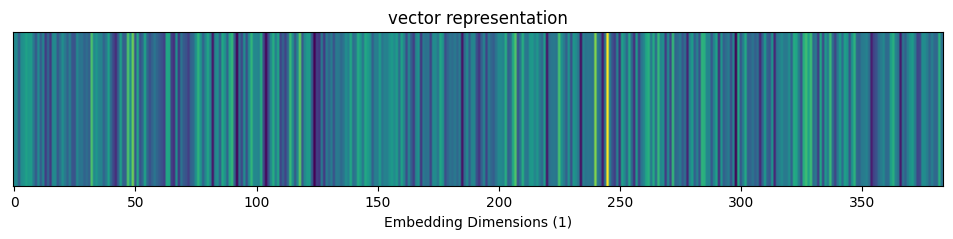

In [39]:
# Retrievel

query = input("Enter your question : ")
query_embedding = model.encode([query])
visualize_embedding(query_embedding,query)

In [40]:
D,I = index.search(np.array(query_embedding),k=5) #looking for 5 similar items
retrieved_chunks = [chunks[i] for i in I[0]]
print("Top retrieved chunks : \n")

for chunk in retrieved_chunks:
  print(chunk.page_content)
  print("Page:",chunk.metadata['page'])
  print("------------------------------------------------")


Top retrieved chunks : 

Sales and Marketing
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.Advertising costs are expensed as incurred. Advertising expense was $2.1 billion, $1.7 billion, and $904 million in ﬁscal years 2025, 2024,and 2023, respectively.
Stock-Based Compensation
Page: 32
------------------------------------------------
Percentage
Change
Sales and marketing 25,654 24,456 5%
As a percent of revenue 9% 10% (1)ppt
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.
Fiscal Year 2025 Compared with Fiscal Year 2024
Page: 19
----------------------------

In [41]:
# Performing Reranking
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
pairs = [(query,chunk.page_content) for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores,retrieved_chunks),
                       key = lambda x:x[0],
                       reverse = True)
print("After reranking :\n")
for score,chunk in ranked_chunks :
  print("score :",score)
  print(chunk.page_content)
  print("Page number :",chunk.metadata["page"])
  print("-------------------------------------------")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


After reranking :

score : 7.960284
Sales and Marketing
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.Advertising costs are expensed as incurred. Advertising expense was $2.1 billion, $1.7 billion, and $904 million in ﬁscal years 2025, 2024,and 2023, respectively.
Stock-Based Compensation
Page number : 32
-------------------------------------------
score : 5.4061546
Percentage
Change
Sales and marketing 25,654 24,456 5%
As a percent of revenue 9% 10% (1)ppt
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.
Fiscal Year 2025 Compared with Fiscal Year 2024
Page 

In [42]:
# Combine rerank chunks with context
top_chunks = [chunk.page_content for _,chunk in ranked_chunks[:3]]
context = "\n\n".join(top_chunks)
print("Context : \n")
print(context)

Context : 

Sales and Marketing
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.Advertising costs are expensed as incurred. Advertising expense was $2.1 billion, $1.7 billion, and $904 million in ﬁscal years 2025, 2024,and 2023, respectively.
Stock-Based Compensation

Percentage
Change
Sales and marketing 25,654 24,456 5%
As a percent of revenue 9% 10% (1)ppt
Sales and marketing expenses include payroll, employee beneﬁts, stock-based compensation expense, and other headcount-related expensesassociated with sales and marketing personnel, and the costs of advertising, promotions, trade shows, seminars, and other programs.
Fiscal Year 2025 Compared with Fiscal Year 2024

charged, prices whensold separately, or estimated costs plus a proﬁt margin. Cost of revenue is allocated 

In [43]:
import google.generativeai as genai
from google.colab import userdata

# 1. Configure Gemini API
GEMINI_API_KEY = userdata.get('GeminiAPI_Key')
genai.configure(api_key=GEMINI_API_KEY)

# 2. Initialize the model with the correct preview string
# 'gemini-3-flash-preview' is the current standard for the free tier
model = genai.GenerativeModel('gemini-3-flash-preview')

# 3. Define your RAG logic
def generate_rag_answer(context, query):
    prompt = f"""
    You are a precise assistant. Answer the question using ONLY the provided context.
    If the answer is not contained within the context, state: "Information not found in document."

    Context:
    {context}

    Question:
    {query}

    Answer:
    """

    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"An error occurred: {e}"

result = generate_rag_answer(context, query)
print(result)

ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3764.10ms


Sales and marketing expenses include payroll, employee benefits, stock-based compensation expense, and other headcount-related expenses for sales and marketing personnel, as well as costs for advertising, promotions, trade shows, seminars, and other programs.

Key financial details include:
*   **Total Expenses:** $25,654 in fiscal year 2025 and $24,456 in fiscal year 2024, representing a 5% change.
*   **Percent of Revenue:** 9% in fiscal year 2025 compared to 10% in fiscal year 2024 (a 1 percentage point decrease).
*   **Advertising Costs:** These are expensed as incurred. Advertising expense was $2.1 billion in fiscal year 2025, $1.7 billion in 2024, and $904 million in 2023.
*   **Allocation:** Marketing expenses that benefit multiple segments are generally allocated based on relative gross margin.


In [44]:
def evaluate_response(query, context, response):
    eval_prompt = f"""
    Evaluate the following RAG response based on the Context.
    Score from 0 to 1 (0 is fail, 1 is perfect).

    1. Faithfulness: Is the answer derived ONLY from the context?
    2. Relevancy: Does the answer actually address the query?

    Query: {query}
    Context: {context}
    Response: {response}

    Return ONLY a JSON: {{"faithfulness": score, "relevancy": score}}
    """
    eval_result = model.generate_content(eval_prompt)
    return eval_result.text



In [45]:
evaluation_result = evaluate_response(query, context, result)
print(evaluation_result)


{"faithfulness": 1.0, "relevancy": 1.0}
